In [2]:
!pip install -q opencv-python scikit-learn seaborn kaggle

In [3]:
import os
import random
import copy
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import cv2

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")
print("PyTorch version:", torch.__version__)

All libraries imported successfully.
PyTorch version: 2.11.0+cu128


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")
    print("Go to Runtime > Change runtime type > T4 GPU")

Device: cuda
GPU: Tesla T4


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = "/content/HAM10000"

IMAGE_SIZE = 224
BATCH_SIZE = 32

NUM_EPOCHS = 5
LEARNING_RATE = 0.0001

NUM_WORKERS = 2

FILTERS = [
    "No Filter",
    "Average",
    "Gaussian",
    "Median",
    "Sharpening",
    "Sobel"
]

print("Configuration ready.")
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Filters:", FILTERS)

Configuration ready.
Image size: 224
Batch size: 32
Epochs: 5
Filters: ['No Filter', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']


In [7]:
import os
from getpass import getpass

kaggle_token = getpass("Enter your Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

print("Kaggle token configured successfully.")

Enter your Kaggle API token: ··········
Kaggle token configured successfully.


In [8]:
import subprocess

result = subprocess.run(
    ["kaggle", "datasets", "list", "-s", "skin-cancer-mnist-ham10000"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("Kaggle connection error:")
    print(result.stderr)
else:
    print("Kaggle connection successful.")

ref                                                               title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                 Skin Cancer MNIST: HAM10000                       5582914511  2018-09-20 20:36:13.037000         287039       2404  0.7058824        
proxzima/skin-cancer-mnist-ham10000-pickle                        Skin Cancer MNIST: HAM10000 (pickle)               389541409  2022-09-10 07:16:58.123000            151          6  0.8125           
discdiver/mnist1000-with-one-image-folder                         MNIST1000_with_one_image_folder                   5543526315  2019-03-20 17:30:54.280000           1114         13  0.5882353        


In [9]:
import os

DATA_DIR = "/content/HAM10000"

os.makedirs(
    DATA_DIR,
    exist_ok=True
)

print(
    "Dataset folder:",
    DATA_DIR
)

Dataset folder: /content/HAM10000


In [10]:
!kaggle datasets download \
-d kmader/skin-cancer-mnist-ham10000 \
-p /content/HAM10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:32<00:00, 174MB/s]



In [11]:
import glob
import os

zip_files = glob.glob(
    "/content/HAM10000/*.zip"
)

print("ZIP files found:")

for file in zip_files:
    print(
        os.path.basename(file)
    )

ZIP files found:
skin-cancer-mnist-ham10000.zip


In [12]:
import zipfile
import glob

zip_files = glob.glob(
    "/content/HAM10000/*.zip"
)

for zip_file in zip_files:

    print(
        "Extracting:",
        zip_file
    )

    with zipfile.ZipFile(
        zip_file,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            "/content/HAM10000"
        )

print("Dataset extracted successfully.")

Extracting: /content/HAM10000/skin-cancer-mnist-ham10000.zip
Dataset extracted successfully.


In [13]:
import glob
import os

csv_files = glob.glob(
    "/content/HAM10000/**/*.csv",
    recursive=True
)

image_files = glob.glob(
    "/content/HAM10000/**/*.jpg",
    recursive=True
)

print("CSV files found:")
for file in csv_files:
    print(file)

print(
    "\nTotal JPG images:",
    len(image_files)
)

CSV files found:
/content/HAM10000/hmnist_8_8_L.csv
/content/HAM10000/hmnist_28_28_RGB.csv
/content/HAM10000/hmnist_8_8_RGB.csv
/content/HAM10000/HAM10000_metadata.csv
/content/HAM10000/hmnist_28_28_L.csv

Total JPG images: 20030


In [14]:
import pandas as pd

metadata_path = None

for file in csv_files:

    if "metadata" in file.lower():

        metadata_path = file
        break

if metadata_path is None:

    metadata_path = csv_files[0]

df = pd.read_csv(
    metadata_path
)

print(
    "Metadata loaded successfully."
)

print(
    "Dataset shape:",
    df.shape
)

display(
    df.head()
)

Metadata loaded successfully.
Dataset shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [15]:
print(
    "Columns:"
)

for column in df.columns:

    print(
        "-",
        column
    )

Columns:
- lesion_id
- image_id
- dx
- dx_type
- age
- sex
- localization


In [16]:
print(
    "Number of classes:",
    df["dx"].nunique()
)

print(
    "\nClasses:"
)

print(
    sorted(df["dx"].unique())
)

print(
    "\nClass distribution:"
)

print(
    df["dx"].value_counts()
)

Number of classes: 7

Classes:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [17]:
class_names = {
    "akiec": "Actinic Keratoses",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesions"
}

for code, name in class_names.items():

    print(
        code,
        "->",
        name
    )

akiec -> Actinic Keratoses
bcc -> Basal Cell Carcinoma
bkl -> Benign Keratosis
df -> Dermatofibroma
mel -> Melanoma
nv -> Melanocytic Nevi
vasc -> Vascular Lesions


In [18]:
image_path_dict = {}

for path in image_files:

    filename = os.path.basename(path)

    image_id = filename.replace(
        ".jpg",
        ""
    )

    image_path_dict[image_id] = path


df["image_path"] = df["image_id"].map(
    image_path_dict
)

df = df.dropna(
    subset=["image_path"]
).reset_index(
    drop=True
)

print(
    "Usable images:",
    len(df)
)

display(
    df[
        [
            "image_id",
            "dx",
            "image_path"
        ]
    ].head()
)

Usable images: 10015


,image_id,dx,image_path
0,ISIC_0027419,bkl,/content/HAM10000/ham10000_images_part_1/ISIC_...
1,ISIC_0025030,bkl,/content/HAM10000/ham10000_images_part_1/ISIC_...
2,ISIC_0026769,bkl,/content/HAM10000/ham10000_images_part_1/ISIC_...
3,ISIC_0025661,bkl,/content/HAM10000/ham10000_images_part_1/ISIC_...
4,ISIC_0031633,bkl,/content/HAM10000/ham10000_images_part_2/ISIC_...


In [20]:
classes = sorted(
    df["dx"].unique()
)

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

df["label"] = df["dx"].map(
    class_to_idx
)

print(
    "Class Mapping:"
)

for key, value in class_to_idx.items():

    print(
        key,
        "->",
        value
    )

Class Mapping:
akiec -> 0
bcc -> 1
bkl -> 2
df -> 3
mel -> 4
nv -> 5
vasc -> 6


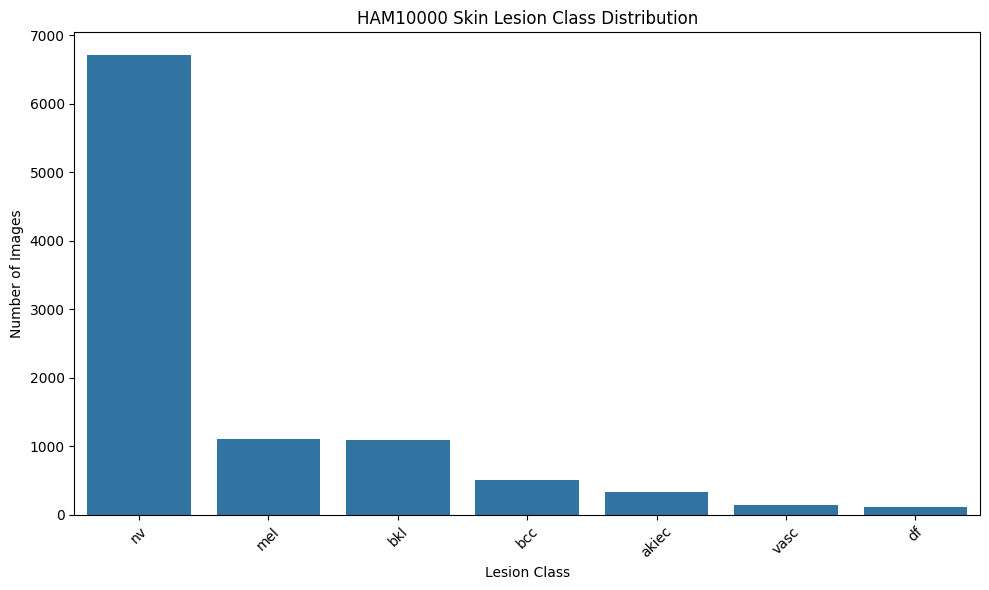

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(
    figsize=(10, 6)
)

counts = df["dx"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.title(
    "HAM10000 Skin Lesion Class Distribution"
)

plt.xlabel(
    "Lesion Class"
)

plt.ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [22]:
from sklearn.model_selection import train_test_split

SEED = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(
    drop=True
)

val_df = val_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print("DATASET SPLIT")
print("-----------------------")

print(
    "Training:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Testing:",
    len(test_df)
)

print(
    "Total:",
    len(train_df)
    + len(val_df)
    + len(test_df)
)

DATASET SPLIT
-----------------------
Training: 8012
Validation: 1001
Testing: 1002
Total: 10015


In [23]:
print("TRAINING DISTRIBUTION")
print(
    train_df["dx"].value_counts()
)

print("\nVALIDATION DISTRIBUTION")
print(
    val_df["dx"].value_counts()
)

print("\nTESTING DISTRIBUTION")
print(
    test_df["dx"].value_counts()
)

TRAINING DISTRIBUTION
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64

VALIDATION DISTRIBUTION
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64

TESTING DISTRIBUTION
dx
nv       671
mel      112
bkl      110
bcc       52
akiec     32
vasc      14
df        11
Name: count, dtype: int64


In [24]:
import cv2
import numpy as np
from PIL import Image

def apply_filter(
    image,
    filter_name
):

    image_np = np.array(
        image
    )

    # No Filter
    if filter_name == "No Filter":

        return image

    # Average / Mean
    elif filter_name == "Average":

        filtered = cv2.blur(
            image_np,
            (5, 5)
        )

    # Gaussian
    elif filter_name == "Gaussian":

        filtered = cv2.GaussianBlur(
            image_np,
            (5, 5),
            0
        )

    # Median
    elif filter_name == "Median":

        filtered = cv2.medianBlur(
            image_np,
            5
        )

    # Sharpening
    elif filter_name == "Sharpening":

        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])

        filtered = cv2.filter2D(
            image_np,
            -1,
            kernel
        )

    # Sobel
    elif filter_name == "Sobel":

        gray = cv2.cvtColor(
            image_np,
            cv2.COLOR_RGB2GRAY
        )

        sobel_x = cv2.Sobel(
            gray,
            cv2.CV_64F,
            1,
            0,
            ksize=3
        )

        sobel_y = cv2.Sobel(
            gray,
            cv2.CV_64F,
            0,
            1,
            ksize=3
        )

        magnitude = np.sqrt(
            sobel_x ** 2 +
            sobel_y ** 2
        )

        magnitude = np.uint8(
            np.clip(
                magnitude,
                0,
                255
            )
        )

        filtered = cv2.cvtColor(
            magnitude,
            cv2.COLOR_GRAY2RGB
        )

    else:

        raise ValueError(
            "Unknown filter: " +
            filter_name
        )

    return Image.fromarray(
        filtered
    )

print(
    "All filters created successfully."
)

All filters created successfully.


In [25]:
FILTERS = [
    "No Filter",
    "Average",
    "Gaussian",
    "Median",
    "Sharpening",
    "Sobel"
]

print(
    FILTERS
)

['No Filter', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']


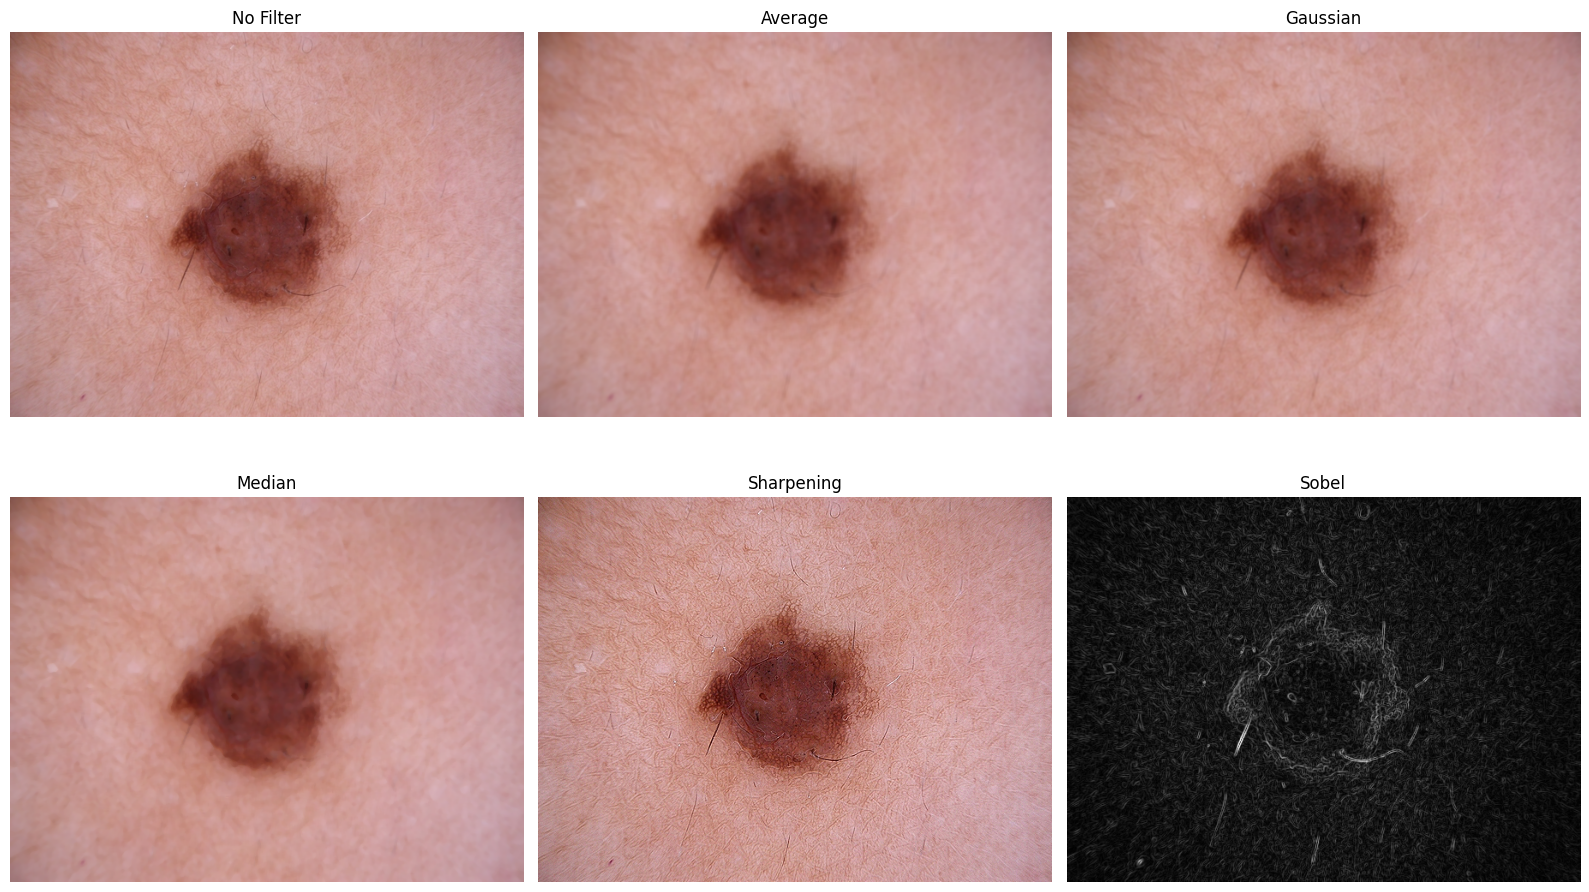

In [26]:
sample_path = train_df.iloc[0][
    "image_path"
]

original_image = Image.open(
    sample_path
).convert("RGB")

plt.figure(
    figsize=(16, 10)
)

for i, filter_name in enumerate(
    FILTERS
):

    filtered_image = apply_filter(
        original_image,
        filter_name
    )

    plt.subplot(
        2,
        3,
        i + 1
    )

    plt.imshow(
        filtered_image
    )

    plt.title(
        filter_name
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [27]:
import torch
import torchvision
from torchvision import models, transforms

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print(
    "Transforms ready."
)

Transforms ready.


In [28]:
from torch.utils.data import Dataset, DataLoader

class SkinLesionDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        filter_name="No Filter",
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.filter_name = filter_name

        self.transform = transform

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = apply_filter(
            image,
            self.filter_name
        )

        if self.transform:

            image = self.transform(
                image
            )

        label = int(
            row["label"]
        )

        return image, label

print(
    "Custom dataset created."
)

Custom dataset created.


In [29]:
def create_dataloaders(
    filter_name
):

    train_dataset = SkinLesionDataset(
        train_df,
        filter_name,
        train_transform
    )

    val_dataset = SkinLesionDataset(
        val_df,
        filter_name,
        eval_transform
    )

    test_dataset = SkinLesionDataset(
        test_df,
        filter_name,
        eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    return (
        train_loader,
        val_loader,
        test_loader
    )

print(
    "DataLoader function ready."
)

DataLoader function ready.


In [30]:
train_loader, val_loader, test_loader = create_dataloaders(
    "No Filter"
)

images, labels = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [31]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [32]:
import torch.nn as nn

NUM_CLASSES = len(
    classes
)

def get_model(
    model_name
):

    if model_name == "EfficientNet-B0":

        weights = (
            models.EfficientNet_B0_Weights.DEFAULT
        )

        model = models.efficientnet_b0(
            weights=weights
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )

    elif model_name == "ResNet50":

        weights = (
            models.ResNet50_Weights.DEFAULT
        )

        model = models.resnet50(
            weights=weights
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )

    elif model_name == "DenseNet121":

        weights = (
            models.DenseNet121_Weights.DEFAULT
        )

        model = models.densenet121(
            weights=weights
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )

    else:

        raise ValueError(
            "Unknown model: " +
            model_name
        )

    return model.to(
        device
    )

In [34]:
MODEL_NAMES = [
    "EfficientNet-B0",
    "ResNet50",
    "DenseNet121"
]

print(
    "Models:"
)

for model_name in MODEL_NAMES:

    print(
        "-",
        model_name
    )

Models:
- EfficientNet-B0
- ResNet50
- DenseNet121


In [35]:
test_model = get_model(
    "EfficientNet-B0"
)

print(
    "EfficientNet-B0 loaded successfully."
)

del test_model

if torch.cuda.is_available():

    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s]


EfficientNet-B0 loaded successfully.


In [36]:
def train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        start_time = time.time()

        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                predictions = torch.argmax(outputs, dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    model.load_state_dict(best_weights)
    return model, history

In [37]:
def evaluate_model(model, test_loader):

    model.eval()
    all_labels, all_predictions, all_probabilities = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    y_prob = np.array(all_probabilities)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        y_true_binary = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
        auc = roc_auc_score(y_true_binary, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan

    metrics = {
        "Accuracy": accuracy, "Precision": precision, "Recall": recall,
        "F1-score": f1, "Macro-F1": macro_f1,
        "Balanced Accuracy": balanced_acc, "AUC": auc
    }

    return metrics, y_true, y_pred, y_prob

In [38]:
all_results = []
all_histories = {}
all_predictions = {}

def run_experiment(model_name, filter_name):

    print("\n" + "="*70)
    print("MODEL:", model_name)
    print("FILTER:", filter_name)
    print("="*70)

    train_loader, val_loader, test_loader = create_dataloaders(filter_name)
    model = get_model(model_name)
    model, history = train_model(model, train_loader, val_loader)
    metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader)

    result = {"Model": model_name, "Filter": filter_name}
    result.update(metrics)
    all_results.append(result)

    key = model_name + "_" + filter_name
    all_histories[key] = history
    all_predictions[key] = {"y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

    print("\nFinal Test Results:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    del model
    torch.cuda.empty_cache()

    return history, metrics

In [39]:
history, metrics = run_experiment("EfficientNet-B0", "No Filter")


MODEL: EfficientNet-B0
FILTER: No Filter
Epoch 1/5 | Train Loss: 0.8212 | Train Acc: 0.7336 | Val Loss: 0.5455 | Val Acc: 0.8092 | Time: 93.9s
Epoch 2/5 | Train Loss: 0.5021 | Train Acc: 0.8203 | Val Loss: 0.4542 | Val Acc: 0.8372 | Time: 90.4s
Epoch 3/5 | Train Loss: 0.3826 | Train Acc: 0.8603 | Val Loss: 0.4029 | Val Acc: 0.8511 | Time: 94.7s
Epoch 4/5 | Train Loss: 0.3085 | Train Acc: 0.8898 | Val Loss: 0.3845 | Val Acc: 0.8551 | Time: 87.2s
Epoch 5/5 | Train Loss: 0.2502 | Train Acc: 0.9124 | Val Loss: 0.3662 | Val Acc: 0.8701 | Time: 87.2s

Final Test Results:
Accuracy: 0.8723
Precision: 0.8697
Recall: 0.8723
F1-score: 0.8698
Macro-F1: 0.7736
Balanced Accuracy: 0.7603
AUC: 0.9771


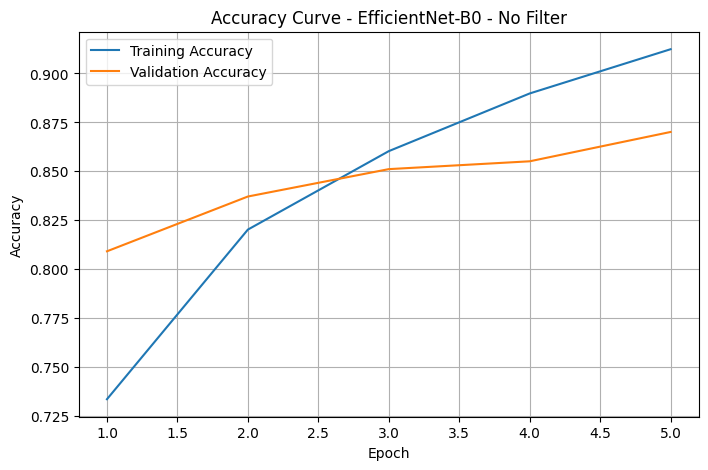

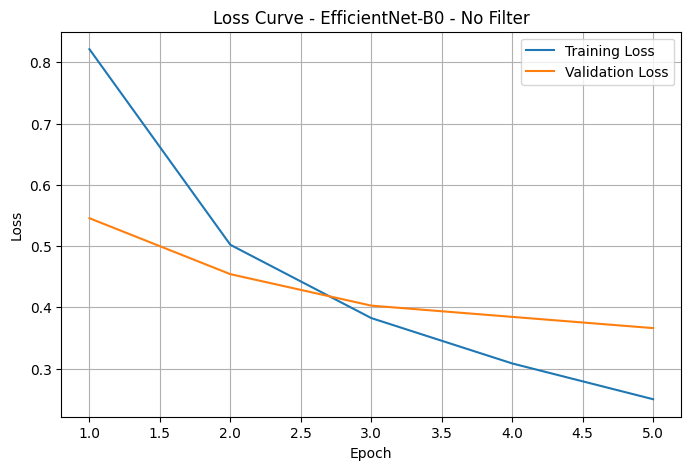

In [40]:
def plot_history(history, model_name, filter_name):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"Accuracy Curve - {model_name} - {filter_name}")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"Loss Curve - {model_name} - {filter_name}")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(); plt.show()

plot_history(history, "EfficientNet-B0", "No Filter")

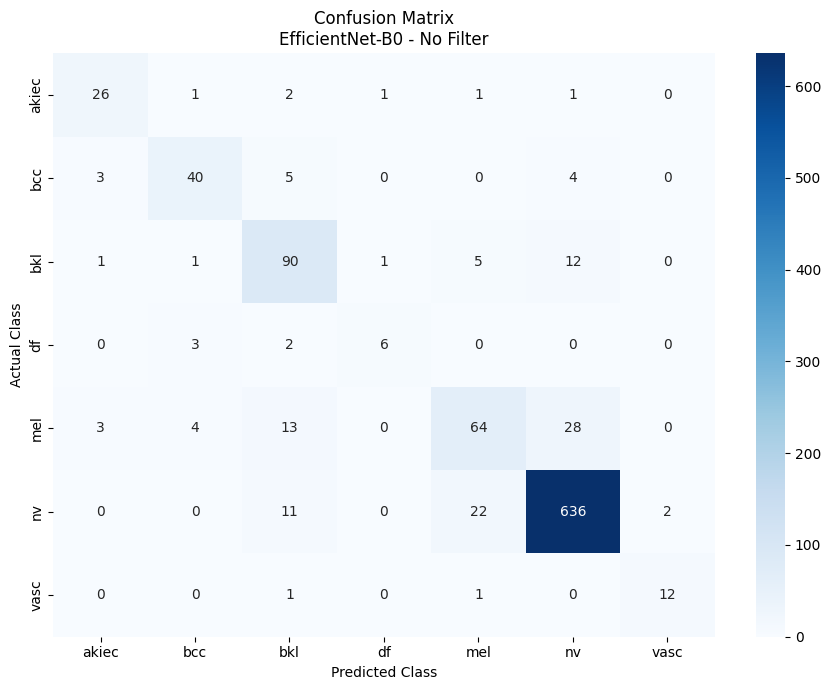

In [41]:
def plot_confusion_matrix(y_true, y_pred, model_name, filter_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix\n{model_name} - {filter_name}")
    plt.xlabel("Predicted Class"); plt.ylabel("Actual Class")
    plt.tight_layout(); plt.show()

test_data = all_predictions["EfficientNet-B0_No Filter"]
plot_confusion_matrix(test_data["y_true"], test_data["y_pred"], "EfficientNet-B0", "No Filter")

In [42]:
def show_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()
    display(report_df.round(4))
    return report_df

show_classification_report(test_data["y_true"], test_data["y_pred"])

,precision,recall,f1-score,support
akiec,0.7879,0.8125,0.8000,32.0000
bcc,0.8163,0.7692,0.7921,52.0000
bkl,0.7258,0.8182,0.7692,110.0000
df,0.7500,0.5455,0.6316,11.0000
mel,0.6882,0.5714,0.6244,112.0000
nv,0.9339,0.9478,0.9408,671.0000
vasc,0.8571,0.8571,0.8571,14.0000
accuracy,0.8723,0.8723,0.8723,0.8723
macro avg,0.7942,0.7603,0.7736,1002.0000
weighted avg,0.8697,0.8723,0.8698,1002.0000


,precision,recall,f1-score,support
akiec,0.787879,0.812500,0.800000,32.000000
bcc,0.816327,0.769231,0.792079,52.000000
bkl,0.725806,0.818182,0.769231,110.000000
df,0.750000,0.545455,0.631579,11.000000
mel,0.688172,0.571429,0.624390,112.000000
nv,0.933921,0.947839,0.940828,671.000000
vasc,0.857143,0.857143,0.857143,14.000000
accuracy,0.872255,0.872255,0.872255,0.872255
macro avg,0.794178,0.760254,0.773607,1002.000000
weighted avg,0.869746,0.872255,0.869839,1002.000000


In [ ]:
all_results = []
all_histories = {}
all_predictions = {}

for model_name in MODEL_NAMES:
    for filter_name in FILTERS:
        try:
            run_experiment(model_name, filter_name)
            print("\nExperiment completed:", model_name, "+", filter_name)
        except Exception as error:
            print("\nERROR:", model_name, "+", filter_name)
            print(error)

print("\nAll experiments finished.")


MODEL: EfficientNet-B0
FILTER: No Filter
Epoch 1/5 | Train Loss: 0.8261 | Train Acc: 0.7277 | Val Loss: 0.5443 | Val Acc: 0.8002 | Time: 90.8s
Epoch 2/5 | Train Loss: 0.4968 | Train Acc: 0.8243 | Val Loss: 0.4615 | Val Acc: 0.8372 | Time: 85.2s
Epoch 3/5 | Train Loss: 0.3815 | Train Acc: 0.8663 | Val Loss: 0.3964 | Val Acc: 0.8601 | Time: 86.5s
Epoch 4/5 | Train Loss: 0.3017 | Train Acc: 0.8927 | Val Loss: 0.3978 | Val Acc: 0.8561 | Time: 84.4s
Epoch 5/5 | Train Loss: 0.2461 | Train Acc: 0.9108 | Val Loss: 0.3766 | Val Acc: 0.8591 | Time: 85.2s

Final Test Results:
Accuracy: 0.8713
Precision: 0.8645
Recall: 0.8713
F1-score: 0.8658
Macro-F1: 0.7509
Balanced Accuracy: 0.7252
AUC: 0.9750

Experiment completed: EfficientNet-B0 + No Filter

MODEL: EfficientNet-B0
FILTER: Average
Epoch 1/5 | Train Loss: 0.8449 | Train Acc: 0.7204 | Val Loss: 0.5518 | Val Acc: 0.8042 | Time: 96.5s
Epoch 2/5 | Train Loss: 0.5105 | Train Acc: 0.8183 | Val Loss: 0.4726 | Val Acc: 0.8172 | Time: 98.2s
Epoch 3/5 

100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


Epoch 1/5 | Train Loss: 0.7604 | Train Acc: 0.7396 | Val Loss: 0.5889 | Val Acc: 0.8062 | Time: 99.3s
Epoch 2/5 | Train Loss: 0.4449 | Train Acc: 0.8392 | Val Loss: 0.4330 | Val Acc: 0.8492 | Time: 100.3s
Epoch 3/5 | Train Loss: 0.3374 | Train Acc: 0.8782 | Val Loss: 0.3987 | Val Acc: 0.8551 | Time: 99.3s
Epoch 4/5 | Train Loss: 0.2644 | Train Acc: 0.9034 | Val Loss: 0.3727 | Val Acc: 0.8731 | Time: 99.9s
Epoch 5/5 | Train Loss: 0.1979 | Train Acc: 0.9287 | Val Loss: 0.3667 | Val Acc: 0.8631 | Time: 101.7s

Final Test Results:
Accuracy: 0.8733
Precision: 0.8717
Recall: 0.8733
F1-score: 0.8705
Macro-F1: 0.7533
Balanced Accuracy: 0.7173
AUC: 0.9832

Experiment completed: ResNet50 + No Filter

MODEL: ResNet50
FILTER: Average
Epoch 1/5 | Train Loss: 0.7679 | Train Acc: 0.7390 | Val Loss: 0.5617 | Val Acc: 0.8002 | Time: 112.9s
Epoch 2/5 | Train Loss: 0.4635 | Train Acc: 0.8324 | Val Loss: 0.4998 | Val Acc: 0.8252 | Time: 112.0s
Epoch 3/5 | Train Loss: 0.3597 | Train Acc: 0.8709 | Val Loss:

100%|██████████| 30.8M/30.8M [00:00<00:00, 127MB/s]


Epoch 1/5 | Train Loss: 0.6843 | Train Acc: 0.7629 | Val Loss: 0.5080 | Val Acc: 0.8222 | Time: 98.4s
Epoch 2/5 | Train Loss: 0.4160 | Train Acc: 0.8474 | Val Loss: 0.4446 | Val Acc: 0.8372 | Time: 97.3s
Epoch 3/5 | Train Loss: 0.3265 | Train Acc: 0.8814 | Val Loss: 0.3976 | Val Acc: 0.8561 | Time: 97.9s
Epoch 4/5 | Train Loss: 0.2638 | Train Acc: 0.9035 | Val Loss: 0.3823 | Val Acc: 0.8711 | Time: 96.6s
Epoch 5/5 | Train Loss: 0.2097 | Train Acc: 0.9261 | Val Loss: 0.4071 | Val Acc: 0.8571 | Time: 96.3s

Final Test Results:
Accuracy: 0.8822
Precision: 0.8785
Recall: 0.8822
F1-score: 0.8747
Macro-F1: 0.7691
Balanced Accuracy: 0.7240
AUC: 0.9800

Experiment completed: DenseNet121 + No Filter

MODEL: DenseNet121
FILTER: Average
Epoch 1/5 | Train Loss: 0.6878 | Train Acc: 0.7662 | Val Loss: 0.5150 | Val Acc: 0.8122 | Time: 109.7s
Epoch 2/5 | Train Loss: 0.4431 | Train Acc: 0.8416 | Val Loss: 0.5285 | Val Acc: 0.8082 | Time: 109.2s
Epoch 3/5 | Train Loss: 0.3537 | Train Acc: 0.8727 | Val L